# 2D Spatial Structure of Sea-Ice Morphology from SWOT KaRIn: A Stability-Relevant Index and Spatial Characterisation

This notebook uses the published Beaufort Sea SWOT-ICESat-2 dataset to answer a question that existing along-track instruments cannot address:

> **What is the 2D spatial structure -- correlation length, anisotropy, and feature orientation -- of sea-ice morphology as measured by SWOT KaRIn?**

It builds a candidate stability-relevant morphology index (SMI) from SWOT 2D height and backscatter fields, validates it against ICESat-2, stress-tests algorithmic choices, tests multi-date persistence, characterises the bathymetric context, and computes the semi-variogram and feature shape metrics of the index.

The output is an interpretable morphology index and its 2D spatial characterisation, not a confirmed ridge, grounding, anchoring, stability, or thickness product.


## Novelty and Scope

### The core question only SWOT can answer

Every published SWOT sea-ice paper treats the swath as a wide along-track altimeter -- profiles, cross-sections, summary statistics. ICESat-2, CryoSat-2, and all prior instruments are inherently one-dimensional. SWOT is the first spaceborne instrument to provide continuous 2D Ka-band height and backscatter at ~250 m resolution across a 100 km swath.

**The question nobody has yet answered:** What is the 2D spatial structure -- spatial correlation length, anisotropy, feature orientation -- of sea-ice morphology as measured by SWOT KaRIn? Does the 2D structure change between seasons? Do high-roughness features have preferred orientations that encode the deformation history?

This cannot be answered with along-track data alone. It requires the full SWOT swath.

### What is already published

- **Kacimi et al. (2025, GRL)** -- *SWOT Observations Over Sea Ice: A First Look.* Lead/floe discrimination and freeboard at 250 m. Does not characterise 2D spatial structure or link morphology to stability.

- **Swath Mapping Altimetry over Sea Ice -- ESS Open Archive preprint (May 2025)** -- Uses this same UMD Beaufort Sea dataset. Ridge detection, 3D freeboard, daily velocity from 1-day repeat. Does not compute spatial autocorrelation, feature anisotropy, or a stability index.

- **Giles et al. (2025, TC)** -- Grounded ridge detection from ICESat-2 along Alaska coast. Along-track only. SWOT not used. Grounding requires water depth < ~50 m.

### What this prototype adds

1. **Stability Morphology Index (SMI)**: a combined height-roughness + backscatter-texture index computed from the full 2D SWOT swath (Sections 4-6).
2. **Algorithmic uncertainty**: sensitivity to window size, threshold, and score components (Section 7).
3. **Multi-date persistence**: Jaccard similarity of high-index features across three dates spanning one day and two months (Section 8).
4. **Bathymetric context**: confirms this scene is over deep Beaufort Basin water (3000-3700 m), ruling out grounded ridge anchoring and scoping future work (Section 9).
5. **2D spatial structure**: semi-variogram, spatial correlation length, feature orientation, and anisotropy -- the first characterisation of these properties from SWOT KaRIn sea-ice data (Section 10).

### Longer-term hypothesis

> SWOT-derived 2D morphology metrics -- spatial correlation length, feature anisotropy, and orientation -- combined with SAR persistence masks, breakout dates, and bathymetry, may help characterise sea-ice mechanical state and evaluate landfast-ice persistence and breakout susceptibility in ways that are inaccessible to along-track instruments.


## Scientific Cautions

- High-index areas are **candidate stability-relevant morphology features** only.
- The index does not confirm grounded ridges, anchor points, thickness anomalies, or stable landfast-ice zones.
- No thickness retrieval is attempted.
- Landfast ice is defined by attachment and low motion, so a stronger version needs SAR persistence or velocity information.
- SWOT sea-ice artifacts remain possible, including swath-side differences, calibration effects, temporal height errors, and along/across-track structure.
- The ICESat-2 comparison in the primary case is spatially overlapping but temporally offset by 8 days, so it is partial support rather than definitive validation.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd

import swot_landfast_utils as swot_utils

warnings.filterwarnings("ignore", category=RuntimeWarning)

DATA_DIR = Path("data/raw")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 220,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})

## 1. Download and Inspect the Zenodo Dataset

Dataset: [SWOT and ICESat-2 Sea Ice Height and Backscatter: Beaufort Sea, selected April - June 2023](https://zenodo.org/records/15238132).

The helper skips the 48-byte placeholder NetCDF and caches the other NetCDF files in `data/raw/`.

In [2]:
file_table = swot_utils.zenodo_file_table()
display(file_table[["key", "size", "checksum"]])

nc_paths = swot_utils.download_zenodo_netcdfs(DATA_DIR)
print(f"Cached {len(nc_paths)} NetCDF files in {DATA_DIR.resolve()}")

,key,size,checksum
0,Fischer_et_al_2025_Data_Description_README.docx,7646373,md5:06276eab1b5374780f434c7565e45074
1,UMD_IC2_0174_BeaufortSea_Study_Region_01_20230...,2719899,md5:03bd27b49df9d89d1744b1bf21c56ee7
2,UMD_IC2_0174_BeaufortSea_Study_Region_02_20230...,19445832,md5:4ad9919a3dee1fb7ad197ffff18a2d81
3,UMD_IC2_0251_BeaufortSea_Study_Region_03_20230...,2170320,md5:c0c3fd48b3760e583f20324ea72429af
4,UMD_SWOT_024_BeaufortSea_Study_Region_01_20230...,180598,md5:33aa5963e738e6de8fe5527b5cf80d7e
5,UMD_SWOT_024_BeaufortSea_Study_Region_02_20230...,48,md5:dfb3616febd977c6320504153a58885f
6,UMD_SWOT_024_BeaufortSea_Study_Region_02_20230...,7217408,md5:ecc1e3d533b904911dcb89a47426ec72
7,UMD_SWOT_024_BeaufortSea_Study_Region_02_20230...,7228331,md5:aa371bfe0ee5378cc084aae65cfe4422
8,UMD_SWOT_024_BeaufortSea_Study_Region_02_20230...,7428993,md5:d85b477dedb71b45fb208f7aa38316b4
9,UMD_SWOT_024_BeaufortSea_Study_Region_02_20230...,7369682,md5:b0ff0c0e4db61497dfcd1f16c9dd3e7c


Cached 9 NetCDF files in C:\Users\as1612\Desktop\swot_landfast_morphology_probe\data\raw


In [3]:
inventory = swot_utils.netcdf_inventory(sorted(DATA_DIR.glob("*.nc")))
display(inventory)

,file,group,variable,dimensions,shape,dtype,units,long_name
0,gebco_bathy_73.55_75.60_-140.87_-135.49.nc,/,elevation,"lat, lon",124 x 323,int16,m,Altitude
1,gebco_bathy_73.55_75.60_-140.87_-135.49.nc,/,lat,lat,124,float64,degrees_north,Latitude
2,gebco_bathy_73.55_75.60_-140.87_-135.49.nc,/,lon,lon,323,float64,degrees_east,Longitude
3,UMD_IC2_0174_BeaufortSea_Study_Region_01_20230...,/gt1l,longitude,x,63540,float64,degrees east,
4,UMD_IC2_0174_BeaufortSea_Study_Region_01_20230...,/gt1l,latitude,x,63540,float64,degrees north,
...,...,...,...,...,...,...,...,...
94,UMD_SWOT_026_BeaufortSea_Study_Region_03_20230...,/left,longitude,"x_along, y_across",1509 x 201,float64,degrees east,
95,UMD_SWOT_026_BeaufortSea_Study_Region_03_20230...,/left,latitude,"x_along, y_across",1509 x 201,float64,degrees north,
96,UMD_SWOT_026_BeaufortSea_Study_Region_03_20230...,/left,datetime,"x_along, y_across",1509 x 201,int32,seconds since 2000-01-01,
97,UMD_SWOT_026_BeaufortSea_Study_Region_03_20230...,/left,sea_ice_height,"x_along, y_across",1509 x 201,float64,m,sea ice height with respect to DTU21MSS


## 2. Select a Beaufort Sea Prototype Case

Primary morphology-index scene:

- SWOT file: `UMD_SWOT_024_BeaufortSea_Study_Region_02_20230409.nc`
- SWOT swath: `left`
- Main SWOT fields: `sea_ice_height` and `backscatter`

ICESat-2 comparison:

- ICESat-2 file: `UMD_IC2_0174_BeaufortSea_Study_Region_02_20230401.nc`
- Beam: `gt2l`
- Fields: `sea_ice_height_20m` and `sea_ice_height_500m`

This pairing gives a clear 2D SWOT scene and an ICESat-2 track crossing the swath. The temporal offset matters: ICESat-2 is from 2023-04-01 and SWOT is from 2023-04-09.

In [4]:
SWOT_FILE = DATA_DIR / "UMD_SWOT_024_BeaufortSea_Study_Region_02_20230409.nc"
SWOT_SWATH = "left"
ICESAT2_FILE = DATA_DIR / "UMD_IC2_0174_BeaufortSea_Study_Region_02_20230401.nc"
ICESAT2_BEAM = "gt2l"

swot = swot_utils.open_swot(SWOT_FILE, swath=SWOT_SWATH)
ic2 = swot_utils.open_icesat2(ICESAT2_FILE, beam=ICESAT2_BEAM)

print(swot)
print(f"ICESat-2 points in beam {ICESAT2_BEAM}: {len(ic2):,}")
print(ic2[["lon", "lat", "distance_m", "height_20m", "height_500m", "height_source"]].head())

<xarray.Dataset> Size: 9MB
Dimensions:   (x_along: 1246, y_across: 201)
Coordinates:
    lon       (x_along, y_across) float64 2MB -141.8 -141.8 ... -133.1 -133.1
    lat       (x_along, y_across) float64 2MB ...
Dimensions without coordinates: x_along, y_across
Data variables:
    datetime  (x_along, y_across) int32 1MB ...
    height    (x_along, y_across) float64 2MB ...
    sigma0    (x_along, y_across) float64 2MB ...
Attributes:
    long_name:       left swath
    source_file:     UMD_SWOT_024_BeaufortSea_Study_Region_02_20230409.nc
    source_path:     data\raw\UMD_SWOT_024_BeaufortSea_Study_Region_02_202304...
    swath:           left
    height_source:   sea_ice_height
    sigma0_source:   backscatter
    product_format:  umd_zenodo
ICESat-2 points in beam gt2l: 472,593
          lon        lat  distance_m  height_20m  height_500m   height_source
0 -137.441476  72.708717  252.748258    0.191054          NaN  sea_ice_height
1 -137.441479  72.708723  253.457193    0.189986     

## 3. Provisional Analysis Mask and Pixel Spacing

The Region 02 SWOT files do not include `ice_type_flag`, so this prototype uses a conservative provisional ice-like analysis mask:

- finite height/freeboard
- finite sigma0/backscatter
- height/freeboard between -1 and 3 m, excluding obvious gross outliers

This is not a landfast-ice mask. It only defines the grid cells where the morphology index is evaluated.

In [5]:
height = swot["height"].values.astype(float)
sigma0 = swot["sigma0"].values.astype(float)
valid_mask, mask_info = swot_utils.provisional_ice_mask(height, sigma0=sigma0)
spacing = swot_utils.infer_pixel_spacing_m(swot["lon"].values, swot["lat"].values)

print(mask_info["criteria"])
print(f"Valid pixels: {valid_mask.sum():,} / {valid_mask.size:,}")
print("Inferred spacing (m):", spacing)
print("Height source:", swot.attrs.get("height_source"))

finite height/freeboard; -1.0 <= height/freeboard <= 3.0 m; finite sigma0/backscatter
Valid pixels: 159,046 / 250,446
Inferred spacing (m): {'along_m': 239.46713586710388, 'across_m': 249.8980091218874, 'median_m': 244.68257249449564}
Height source: sea_ice_height


## 4. Build the Stability Morphology Index

Metrics are computed for 500 m, 1 km, and 2 km windows. The 1 km window is used for the main map and cross-section.

The combined stability morphology index (SMI) is:

```text
SMI = z(local height/freeboard standard deviation)
    + z(height/freeboard gradient magnitude)
    + z(local sigma0/backscatter standard deviation)
```

Two component variants are also retained for uncertainty testing:

- `height_only_smi = z(local height/freeboard std) + z(height/freeboard gradient magnitude)`
- `backscatter_only_smi = z(local sigma0/backscatter std)`

Pixels above a threshold are called **high-index roughness features** or **candidate stability-relevant morphology features**.

In [6]:
WINDOWS_M = [500, 1000, 2000]
metrics_by_window = {
    window_m: swot_utils.compute_morphology(swot, window_m=window_m, valid_mask=valid_mask)
    for window_m in WINDOWS_M
}
metrics = metrics_by_window[1000]
smi = metrics["stability_morphology_index"].values
valid = metrics["valid_mask"].values.astype(bool)

high_index_mask, high_index_threshold, high_index_label = swot_utils.index_mask(
    smi, valid_mask=valid, quantile=0.90
)
feature_labels, high_index_features = swot_utils.label_index_features(high_index_mask, spacing=spacing, min_pixels=4)

print(metrics.attrs)
print(f"SMI threshold ({high_index_label}): {high_index_threshold:.3f}")
print(f"High-index pixels: {high_index_mask.sum():,}")
display(high_index_features.sort_values("area_km2", ascending=False).head(15))

{'window_m': 1000.0, 'window_pixels_along': 4, 'window_pixels_across': 4, 'spacing_along_m': 239.46713586710388, 'spacing_across_m': 249.8980091218874, 'mask_criteria': 'user-supplied valid mask', 'smi_definition': 'z(local height/freeboard std) + z(height/freeboard gradient magnitude) + z(local sigma0 std)', 'height_only_smi_definition': 'z(local height/freeboard std) + z(height/freeboard gradient magnitude)', 'backscatter_only_smi_definition': 'z(local sigma0 std)'}
SMI threshold (top 10%): 2.528
High-index pixels: 15,886


,feature_id,pixel_count,area_km2
29,30,1079,64.569907
81,82,1012,60.560469
6,7,866,51.823484
375,376,552,33.032983
209,210,501,29.981023
0,1,487,29.143230
391,392,380,22.740097
400,401,264,15.798383
431,432,226,13.524373
403,404,211,12.626738


## 5. ICESat-2 Comparison

ICESat-2 points are sampled against the SWOT SMI with nearest-neighbor matching in a local projected coordinate system. Matches farther than 750 m from a valid SWOT SMI cell are dropped.

The comparison checks whether high-index SWOT areas correspond to elevated ICESat-2 height or local along-track variability. The simple variability diagnostic is `abs(height_20m - height_500m)`.

In [7]:
sampled_smi = swot_utils.sample_grid_nearest(
    swot["lon"].values,
    swot["lat"].values,
    smi,
    ic2["lon"].values,
    ic2["lat"].values,
    max_distance_m=750,
    valid_mask=valid,
).rename(columns={"sampled_value": "swot_smi"})

sampled_height = swot_utils.sample_grid_nearest(
    swot["lon"].values,
    swot["lat"].values,
    swot["height"].values,
    ic2["lon"].values,
    ic2["lat"].values,
    max_distance_m=750,
    valid_mask=valid,
).rename(columns={"sampled_value": "swot_height"})[["swot_height"]]

points = pd.concat([ic2.reset_index(drop=True), sampled_smi, sampled_height], axis=1)
points["high_smi_sample"] = points["swot_smi"] >= high_index_threshold
points["ic2_abs_20m_minus_500m"] = (points["height_20m"] - points["height_500m"]).abs()
points_valid = points[np.isfinite(points["swot_smi"])].copy()

q95 = points_valid["swot_smi"].quantile(0.95)
top5 = points_valid[points_valid["swot_smi"] >= q95]
background = points_valid[points_valid["swot_smi"] < q95]
comparison = pd.DataFrame(
    {
        "group": ["top 5% sampled SMI", "background sampled SMI"],
        "n_points": [len(top5), len(background)],
        "mean_ic2_height_20m_m": [top5["height_20m"].mean(), background["height_20m"].mean()],
        "p95_ic2_height_20m_m": [top5["height_20m"].quantile(0.95), background["height_20m"].quantile(0.95)],
        "mean_abs_20m_minus_500m_m": [top5["ic2_abs_20m_minus_500m"].mean(), background["ic2_abs_20m_minus_500m"].mean()],
    }
)

print(f"Matched ICESat-2 points: {len(points_valid):,} / {len(points):,}")
display(comparison)

Matched ICESat-2 points: 106,422 / 472,593


,group,n_points,mean_ic2_height_20m_m,p95_ic2_height_20m_m,mean_abs_20m_minus_500m_m
0,top 5% sampled SMI,5342,0.259094,0.596607,0.087473
1,background sampled SMI,101080,0.239981,0.552007,0.066994


### ICESat-2 roughness correlation

A point-level scatter (hexbin) of SWOT SMI versus ICESat-2 local along-track height variability `|h20m - h500m|` for all matched points. If the index tracks real morphological signal the two should be positively correlated. Spearman rho is used because neither variable is normally distributed.


Spearman rho = 0.194, p = 0.00e+00, n = 106,422


WindowsPath('figures/smi_ic2_roughness_scatter_region02_left_gt2l.png')

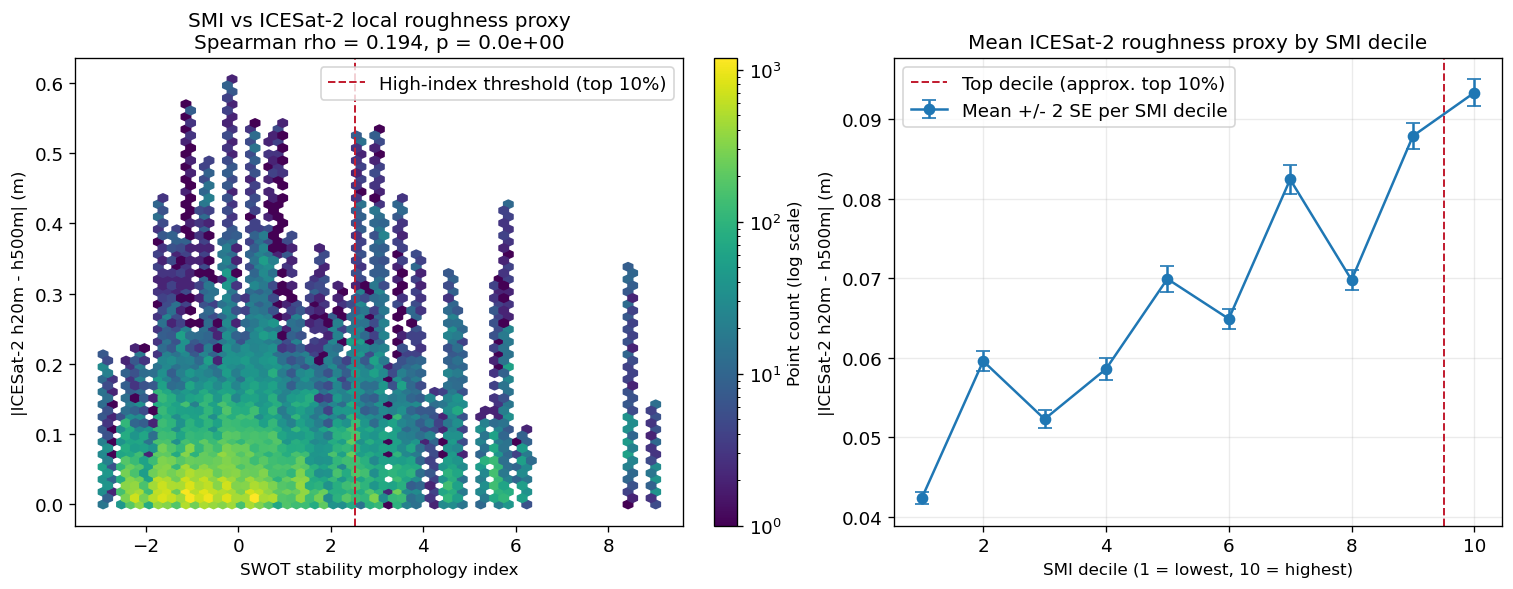

In [8]:
from scipy.stats import spearmanr

scatter_valid = points_valid[
    np.isfinite(points_valid["swot_smi"]) & np.isfinite(points_valid["ic2_abs_20m_minus_500m"])
].copy()

rho, pval = spearmanr(scatter_valid["swot_smi"], scatter_valid["ic2_abs_20m_minus_500m"])
print(f"Spearman rho = {rho:.3f}, p = {pval:.2e}, n = {len(scatter_valid):,}")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), constrained_layout=True)

hb = axes[0].hexbin(
    scatter_valid["swot_smi"],
    scatter_valid["ic2_abs_20m_minus_500m"],
    gridsize=60, mincnt=1, cmap="viridis", bins="log",
)
axes[0].axvline(high_index_threshold, color="#c21f32", linestyle="--", linewidth=1.2,
                label=f"High-index threshold ({high_index_label})")
axes[0].set_xlabel("SWOT stability morphology index")
axes[0].set_ylabel("|ICESat-2 h20m - h500m| (m)")
axes[0].set_title(
    f"SMI vs ICESat-2 local roughness proxy\nSpearman rho = {rho:.3f}, p = {pval:.1e}"
)
axes[0].legend(frameon=True)
fig.colorbar(hb, ax=axes[0], label="Point count (log scale)")

smi_deciles = pd.qcut(scatter_valid["swot_smi"], q=10, labels=False)
binned = scatter_valid.groupby(smi_deciles)["ic2_abs_20m_minus_500m"].agg(["mean", "sem"]).reset_index()
axes[1].errorbar(
    binned.index + 1, binned["mean"], yerr=2 * binned["sem"],
    marker="o", color="#1f77b4", linewidth=1.5, capsize=4,
    label="Mean +/- 2 SE per SMI decile",
)
axes[1].axvline(9.5, color="#c21f32", linestyle="--", linewidth=1.2, label="Top decile (approx. top 10%)")
axes[1].set_xlabel("SMI decile (1 = lowest, 10 = highest)")
axes[1].set_ylabel("|ICESat-2 h20m - h500m| (m)")
axes[1].set_title("Mean ICESat-2 roughness proxy by SMI decile")
axes[1].legend(frameon=True)
axes[1].grid(alpha=0.25)

fig_path = FIG_DIR / "smi_ic2_roughness_scatter_region02_left_gt2l.png"
fig.savefig(fig_path, bbox_inches="tight")
fig_path


In [9]:
# Choose a cross-section centered on a high-SMI point with elevated ICESat-2 variability.
eligible = points_valid[
    np.isfinite(points_valid["distance_m"])
    & np.isfinite(points_valid["height_20m"])
    & np.isfinite(points_valid["height_500m"])
].copy()
eligible_top = eligible[eligible["swot_smi"] >= eligible["swot_smi"].quantile(0.95)].copy()
center_distance = float(
    eligible_top.sort_values("ic2_abs_20m_minus_500m", ascending=False).iloc[0]["distance_m"]
)
segment = eligible[
    (eligible["distance_m"] >= center_distance - 15_000)
    & (eligible["distance_m"] <= center_distance + 15_000)
].sort_values("distance_m")

print(f"Cross-section center distance: {center_distance/1000:.2f} km")
print(f"Segment points: {len(segment):,}")

Cross-section center distance: 244.72 km
Segment points: 41,855


## 6. Main Figures

WindowsPath('figures/four_panel_smi_region02_left_20230409.png')

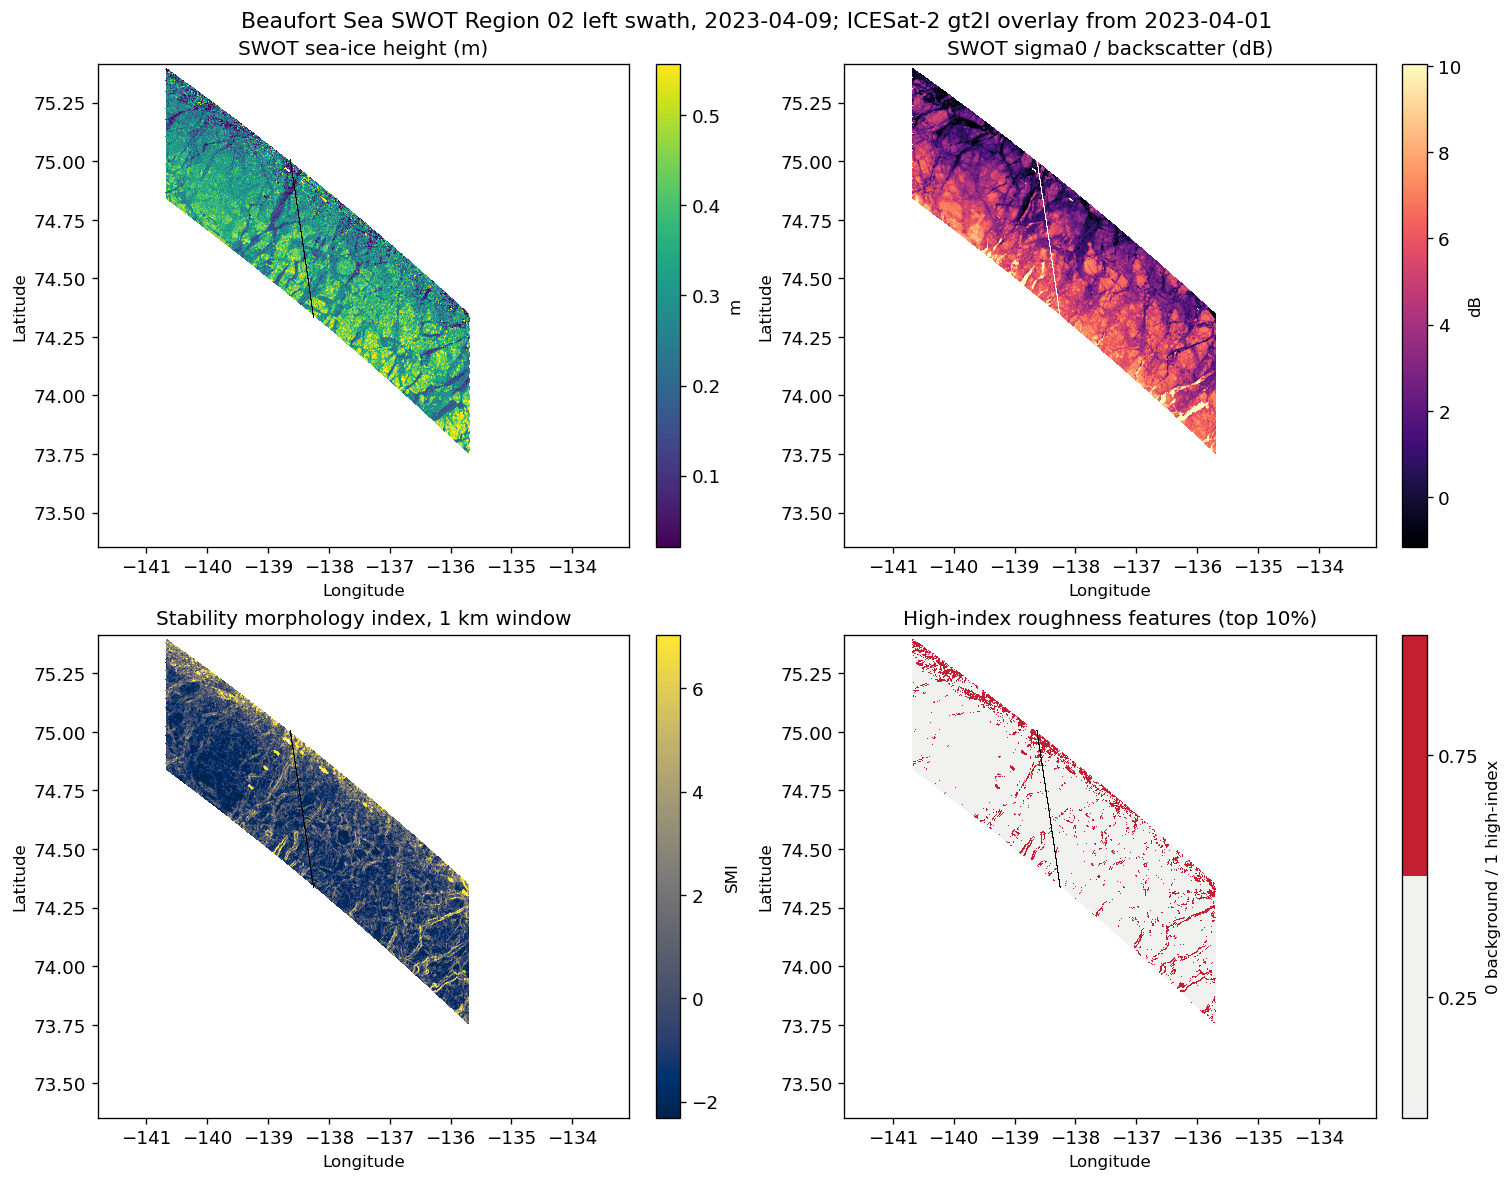

In [10]:
def add_track(ax, frame, color="black", alpha=0.28, size=0.3):
    ax.scatter(frame["lon"], frame["lat"], s=size, c=color, alpha=alpha, linewidths=0, label="ICESat-2 gt2l")

lon = swot["lon"].values
lat = swot["lat"].values
masked_height = np.where(valid, height, np.nan)
masked_sigma0 = np.where(valid, sigma0, np.nan)
masked_smi = np.where(valid, smi, np.nan)
masked_high_index = np.where(valid, high_index_mask.astype(float), np.nan)

height_limits = (np.nanpercentile(masked_height, 1), np.nanpercentile(masked_height, 99))
sigma_limits = (np.nanpercentile(masked_sigma0, 1), np.nanpercentile(masked_sigma0, 99))
smi_limits = (np.nanpercentile(masked_smi, 5), np.nanpercentile(masked_smi, 99))

fig, axes = plt.subplots(2, 2, figsize=(12.5, 9.5), constrained_layout=True)

im = axes[0, 0].pcolormesh(lon, lat, masked_height, shading="auto", cmap="viridis", vmin=height_limits[0], vmax=height_limits[1])
add_track(axes[0, 0], points_valid)
axes[0, 0].set_title("SWOT sea-ice height (m)")
fig.colorbar(im, ax=axes[0, 0], label="m")

im = axes[0, 1].pcolormesh(lon, lat, masked_sigma0, shading="auto", cmap="magma", vmin=sigma_limits[0], vmax=sigma_limits[1])
add_track(axes[0, 1], points_valid, color="white", alpha=0.30)
axes[0, 1].set_title("SWOT sigma0 / backscatter (dB)")
fig.colorbar(im, ax=axes[0, 1], label="dB")

im = axes[1, 0].pcolormesh(lon, lat, masked_smi, shading="auto", cmap="cividis", vmin=smi_limits[0], vmax=smi_limits[1])
add_track(axes[1, 0], points_valid)
axes[1, 0].set_title("Stability morphology index, 1 km window")
fig.colorbar(im, ax=axes[1, 0], label="SMI")

mask_cmap = ListedColormap(["#f1f1ef", "#c21f32"])
im = axes[1, 1].pcolormesh(lon, lat, masked_high_index, shading="auto", cmap=mask_cmap, vmin=0, vmax=1)
add_track(axes[1, 1], points_valid)
axes[1, 1].set_title(f"High-index roughness features ({high_index_label})")
fig.colorbar(im, ax=axes[1, 1], ticks=[0.25, 0.75], label="0 background / 1 high-index")

for ax in axes.flat:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("auto")

fig.suptitle("Beaufort Sea SWOT Region 02 left swath, 2023-04-09; ICESat-2 gt2l overlay from 2023-04-01", y=1.02)
fig_path = FIG_DIR / "four_panel_smi_region02_left_20230409.png"
fig.savefig(fig_path, bbox_inches="tight")
fig_path

WindowsPath('figures/icesat2_smi_cross_section_region02_left_gt2l.png')

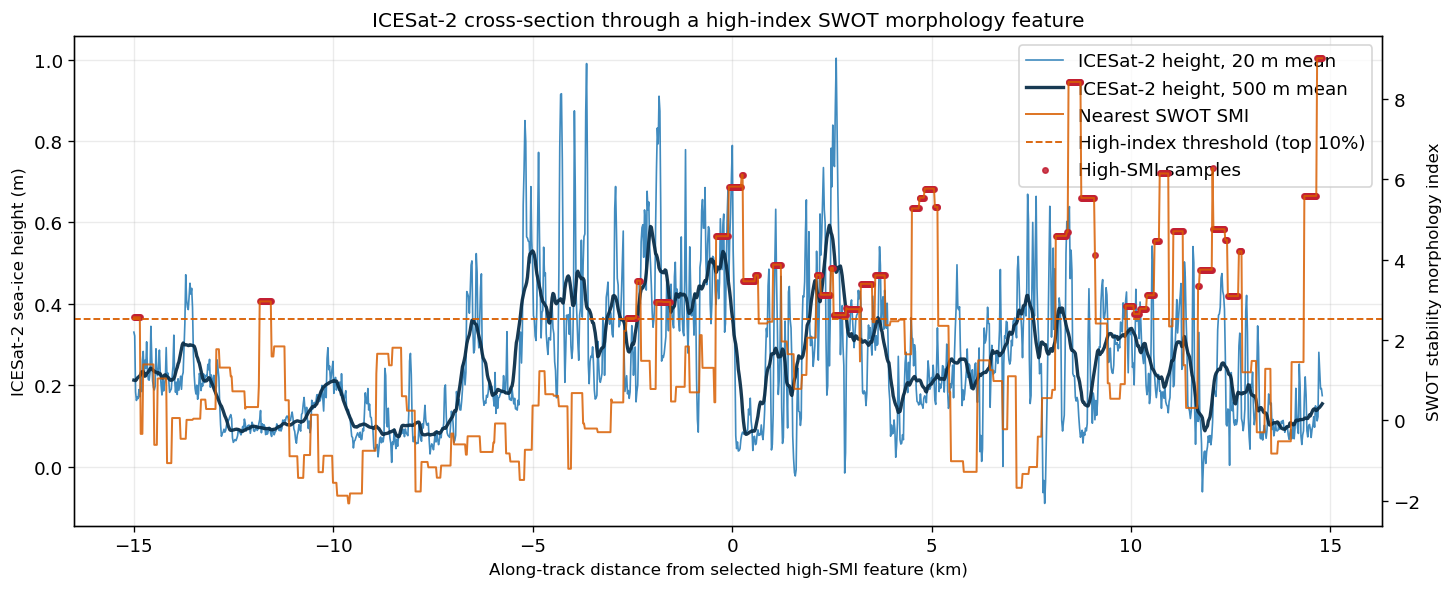

In [11]:
seg = segment.copy()
seg["x_km"] = (seg["distance_m"] - center_distance) / 1000.0
# Thin dense 0.7 m ICESat-2 sampling for plotting while keeping the overall structure.
plot_seg = seg.iloc[::30].copy()

fig, ax1 = plt.subplots(figsize=(12, 4.8), constrained_layout=True)
ax2 = ax1.twinx()

ax1.plot(plot_seg["x_km"], plot_seg["height_20m"], color="#1f77b4", linewidth=1.0, alpha=0.85, label="ICESat-2 height, 20 m mean")
ax1.plot(plot_seg["x_km"], plot_seg["height_500m"], color="#0b2f4a", linewidth=2.0, alpha=0.95, label="ICESat-2 height, 500 m mean")
ax2.plot(plot_seg["x_km"], plot_seg["swot_smi"], color="#d95f02", linewidth=1.2, alpha=0.85, label="Nearest SWOT SMI")
ax2.axhline(high_index_threshold, color="#d95f02", linestyle="--", linewidth=1.1, label=f"High-index threshold ({high_index_label})")

high_plot = plot_seg[plot_seg["swot_smi"] >= high_index_threshold]
ax2.scatter(high_plot["x_km"], high_plot["swot_smi"], s=10, color="#c21f32", alpha=0.85, label="High-SMI samples")

ax1.set_xlabel("Along-track distance from selected high-SMI feature (km)")
ax1.set_ylabel("ICESat-2 sea-ice height (m)")
ax2.set_ylabel("SWOT stability morphology index")
ax1.set_title("ICESat-2 cross-section through a high-index SWOT morphology feature")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", frameon=True)
ax1.grid(alpha=0.25)

fig_path = FIG_DIR / "icesat2_smi_cross_section_region02_left_gt2l.png"
fig.savefig(fig_path, bbox_inches="tight")
fig_path

WindowsPath('figures/smi_histogram_region02_left_20230409.png')

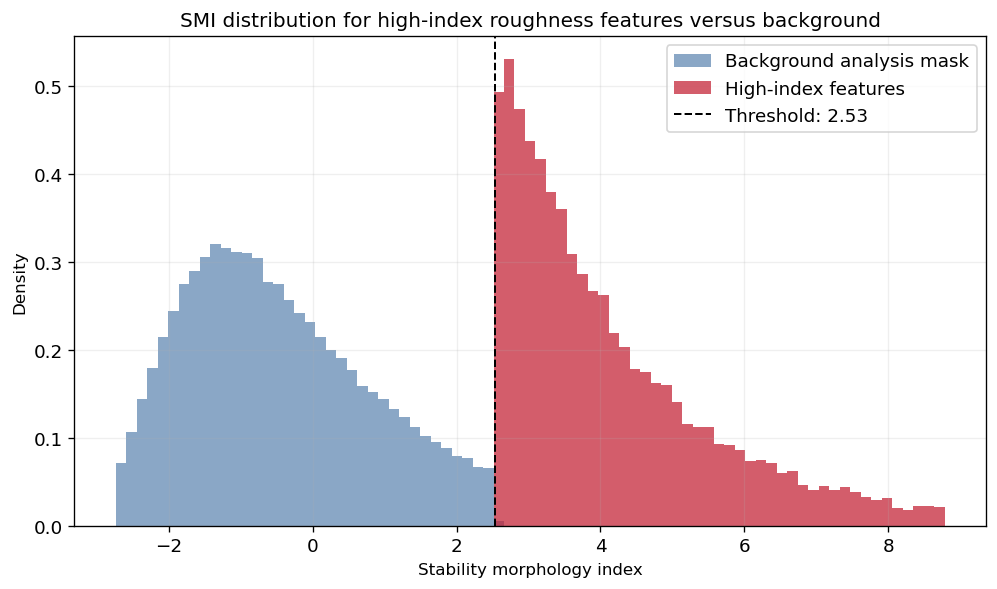

In [12]:
fig, ax = plt.subplots(figsize=(8.2, 4.8), constrained_layout=True)
background_smi = smi[valid & ~high_index_mask]
high_smi = smi[high_index_mask]
bins = np.linspace(np.nanpercentile(smi[valid], 1), np.nanpercentile(smi[valid], 99.5), 80)
ax.hist(background_smi, bins=bins, density=True, alpha=0.65, color="#4c78a8", label="Background analysis mask")
ax.hist(high_smi, bins=bins, density=True, alpha=0.72, color="#c21f32", label="High-index features")
ax.axvline(high_index_threshold, color="black", linestyle="--", linewidth=1.2, label=f"Threshold: {high_index_threshold:.2f}")
ax.set_xlabel("Stability morphology index")
ax.set_ylabel("Density")
ax.set_title("SMI distribution for high-index roughness features versus background")
ax.legend(frameon=True)
ax.grid(alpha=0.2)

fig_path = FIG_DIR / "smi_histogram_region02_left_20230409.png"
fig.savefig(fig_path, bbox_inches="tight")
fig_path

## 7. Algorithmic Uncertainty Layer

For this prototype, the most immediate validation layer is algorithmic uncertainty. The notebook tests whether the SMI changes dramatically under reasonable choices in:

- window size: 500 m, 1 km, and 2 km;
- threshold: top 5 percent, top 10 percent, and greater than 2 standard deviations above background;
- score components: height-only, backscatter-only, and combined SMI;
- swath/artifact checks: row/column median structure and left/right swath comparison for the same date.

,index_variant,window_m,window_pixels_along,window_pixels_across,threshold,threshold_value,high_index_pixels,high_index_area_km2,feature_count
0,stability_morphology_index,500.0,2,2,top 10%,2.428735,15886,950.655739,579
1,stability_morphology_index,500.0,2,2,top 5%,3.710608,7943,475.327869,369
2,stability_morphology_index,500.0,2,2,>2 SD above background,4.512173,5203,311.359802,271
3,stability_morphology_index,1000.0,4,4,top 10%,2.527558,15886,950.655739,448
4,stability_morphology_index,1000.0,4,4,top 5%,3.782623,7943,475.327869,290
5,stability_morphology_index,1000.0,4,4,>2 SD above background,4.620048,5117,306.213359,218
6,stability_morphology_index,2000.0,8,8,top 10%,2.517259,15884,950.536054,252
7,stability_morphology_index,2000.0,8,8,top 5%,3.769398,7942,475.268027,167
8,stability_morphology_index,2000.0,8,8,>2 SD above background,4.466983,5515,330.030618,141


WindowsPath('figures/smi_window_threshold_sensitivity_region02_left_20230409.png')

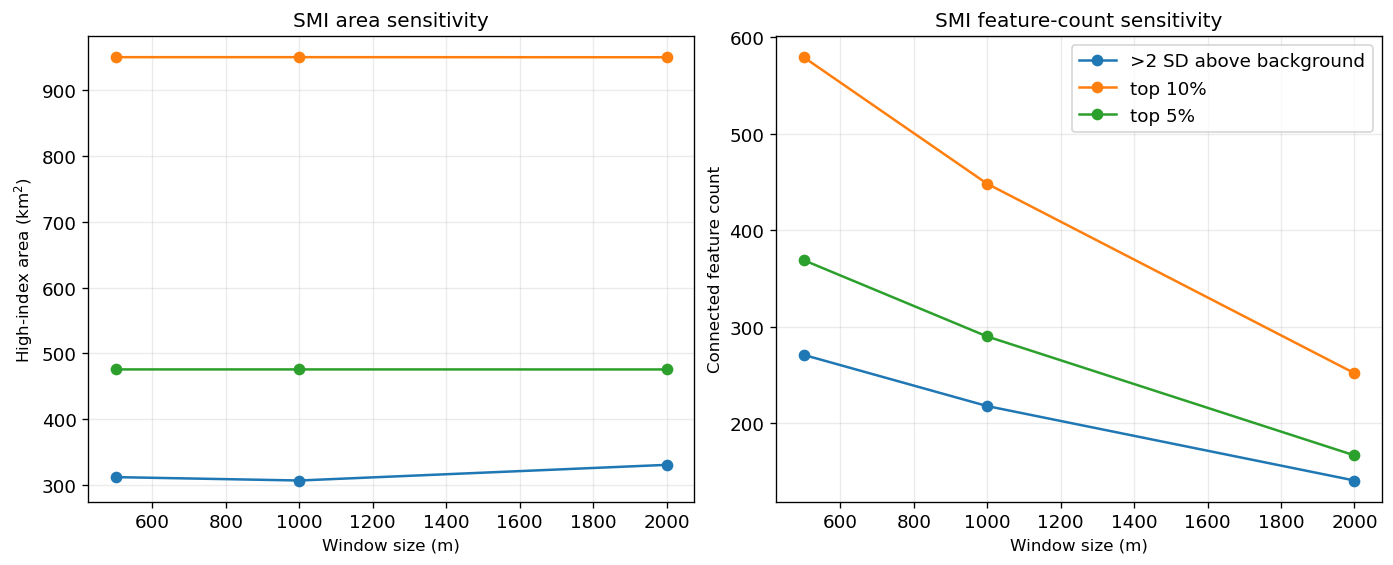

In [13]:
window_threshold_sensitivity = swot_utils.sensitivity_table(
    metrics_by_window,
    thresholds=(0.90, 0.95, "mean+2sd"),
    min_pixels=4,
    index_var="stability_morphology_index",
)
display(window_threshold_sensitivity)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), constrained_layout=True)
for label, group in window_threshold_sensitivity.groupby("threshold"):
    group = group.sort_values("window_m")
    axes[0].plot(group["window_m"], group["high_index_area_km2"], marker="o", label=label)
    axes[1].plot(group["window_m"], group["feature_count"], marker="o", label=label)

axes[0].set_xlabel("Window size (m)")
axes[0].set_ylabel("High-index area (km$^2$)")
axes[0].set_title("SMI area sensitivity")
axes[0].grid(alpha=0.25)

axes[1].set_xlabel("Window size (m)")
axes[1].set_ylabel("Connected feature count")
axes[1].set_title("SMI feature-count sensitivity")
axes[1].grid(alpha=0.25)
axes[1].legend(frameon=True)

fig_path = FIG_DIR / "smi_window_threshold_sensitivity_region02_left_20230409.png"
fig.savefig(fig_path, bbox_inches="tight")
fig_path

,index_variant,threshold,threshold_value,high_index_pixels,high_index_area_km2,feature_count
0,height_only_smi,top 10%,1.837553,15886,950.655739,527
1,height_only_smi,top 5%,2.838413,7943,475.327869,306
2,height_only_smi,>2 SD above background,3.756063,4369,261.451273,168
3,backscatter_only_smi,top 10%,1.167827,15886,950.655739,416
4,backscatter_only_smi,top 5%,1.846872,7943,475.327869,226
5,backscatter_only_smi,>2 SD above background,2.000000,6874,411.356386,209
6,stability_morphology_index,top 10%,2.527558,15886,950.655739,448
7,stability_morphology_index,top 5%,3.782623,7943,475.327869,290
8,stability_morphology_index,>2 SD above background,4.620048,5117,306.213359,218


WindowsPath('figures/smi_component_sensitivity_region02_left_20230409.png')

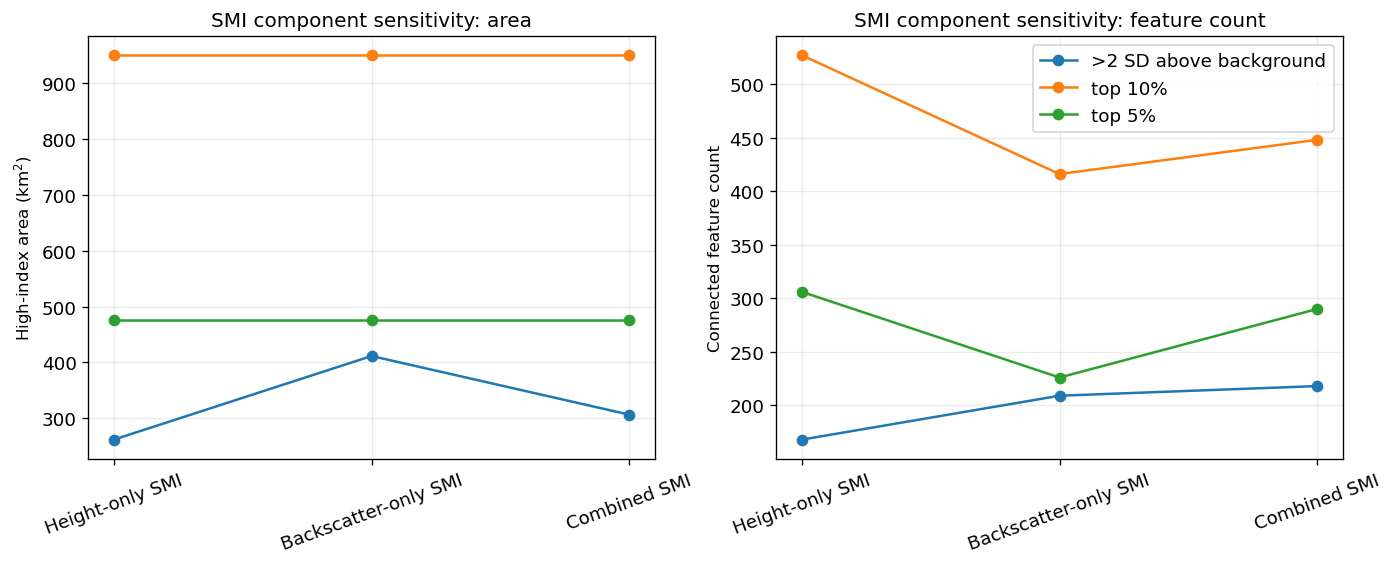

In [14]:
component_sensitivity = swot_utils.component_sensitivity_table(
    metrics,
    index_vars=("height_only_smi", "backscatter_only_smi", "stability_morphology_index"),
    thresholds=(0.90, 0.95, "mean+2sd"),
    min_pixels=4,
)
display(component_sensitivity)

variant_labels = {
    "height_only_smi": "Height-only SMI",
    "backscatter_only_smi": "Backscatter-only SMI",
    "stability_morphology_index": "Combined SMI",
}

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), constrained_layout=True)
for threshold, group in component_sensitivity.groupby("threshold"):
    group = group.copy()
    group["label"] = group["index_variant"].map(variant_labels)
    axes[0].plot(group["label"], group["high_index_area_km2"], marker="o", label=threshold)
    axes[1].plot(group["label"], group["feature_count"], marker="o", label=threshold)

for ax in axes:
    ax.tick_params(axis="x", rotation=20)
    ax.grid(alpha=0.25)

axes[0].set_ylabel("High-index area (km$^2$)")
axes[0].set_title("SMI component sensitivity: area")
axes[1].set_ylabel("Connected feature count")
axes[1].set_title("SMI component sensitivity: feature count")
axes[1].legend(frameon=True)

fig_path = FIG_DIR / "smi_component_sensitivity_region02_left_20230409.png"
fig.savefig(fig_path, bbox_inches="tight")
fig_path

In [15]:
axis_summary_left = swot_utils.swath_axis_artifact_summary(smi, valid)
axis_summary_left["swath"] = "left"

right_swot = swot_utils.open_swot(SWOT_FILE, swath="right")
right_height = right_swot["height"].values.astype(float)
right_sigma0 = right_swot["sigma0"].values.astype(float)
right_mask, _ = swot_utils.provisional_ice_mask(right_height, sigma0=right_sigma0)
right_metrics = swot_utils.compute_morphology(right_swot, window_m=1000, valid_mask=right_mask)
right_smi = right_metrics["stability_morphology_index"].values
axis_summary_right = swot_utils.swath_axis_artifact_summary(right_smi, right_mask)
axis_summary_right["swath"] = "right"

swath_summary = []
for name, metrics_i in [("left", metrics), ("right", right_metrics)]:
    valid_i = metrics_i["valid_mask"].values.astype(bool)
    smi_i = metrics_i["stability_morphology_index"].values
    mask_i, thresh_i, label_i = swot_utils.index_mask(smi_i, valid_mask=valid_i, quantile=0.90)
    spacing_i = {
        "along_m": float(metrics_i.attrs["spacing_along_m"]),
        "across_m": float(metrics_i.attrs["spacing_across_m"]),
    }
    _, features_i = swot_utils.label_index_features(mask_i, spacing=spacing_i, min_pixels=4)
    pixel_area = spacing_i["along_m"] * spacing_i["across_m"] / 1e6
    swath_summary.append({
        "swath": name,
        "valid_pixels": int(valid_i.sum()),
        "smi_p95": float(np.nanpercentile(smi_i[valid_i], 95)),
        "smi_p99": float(np.nanpercentile(smi_i[valid_i], 99)),
        "top10_threshold": thresh_i,
        "top10_area_km2": float(mask_i.sum() * pixel_area),
        "top10_feature_count": int(len(features_i)),
    })

artifact_summary = pd.concat([axis_summary_left, axis_summary_right], ignore_index=True)
swath_summary = pd.DataFrame(swath_summary)
print("Axis-median SMI diagnostics:")
display(artifact_summary)

print("Left/right swath comparison for the same date and window:")
display(swath_summary)

Axis-median SMI diagnostics:


,axis,median_of_axis_medians,std_of_axis_medians,p95_abs_axis_median,swath
0,along-track rows,-0.431109,0.938316,1.909080,left
1,across-track columns,-0.671644,0.908433,1.698034,left
2,along-track rows,-0.487551,0.629753,1.503118,right
3,across-track columns,-0.734180,0.635086,1.148617,right


Left/right swath comparison for the same date and window:


,swath,valid_pixels,smi_p95,smi_p99,top10_threshold,top10_area_km2,top10_feature_count
0,left,159046,3.782623,7.039204,2.527558,950.655739,448
1,right,167634,3.731787,6.483508,2.579733,1001.975260,581


WindowsPath('figures/smi_artifact_checks_region02_20230409.png')

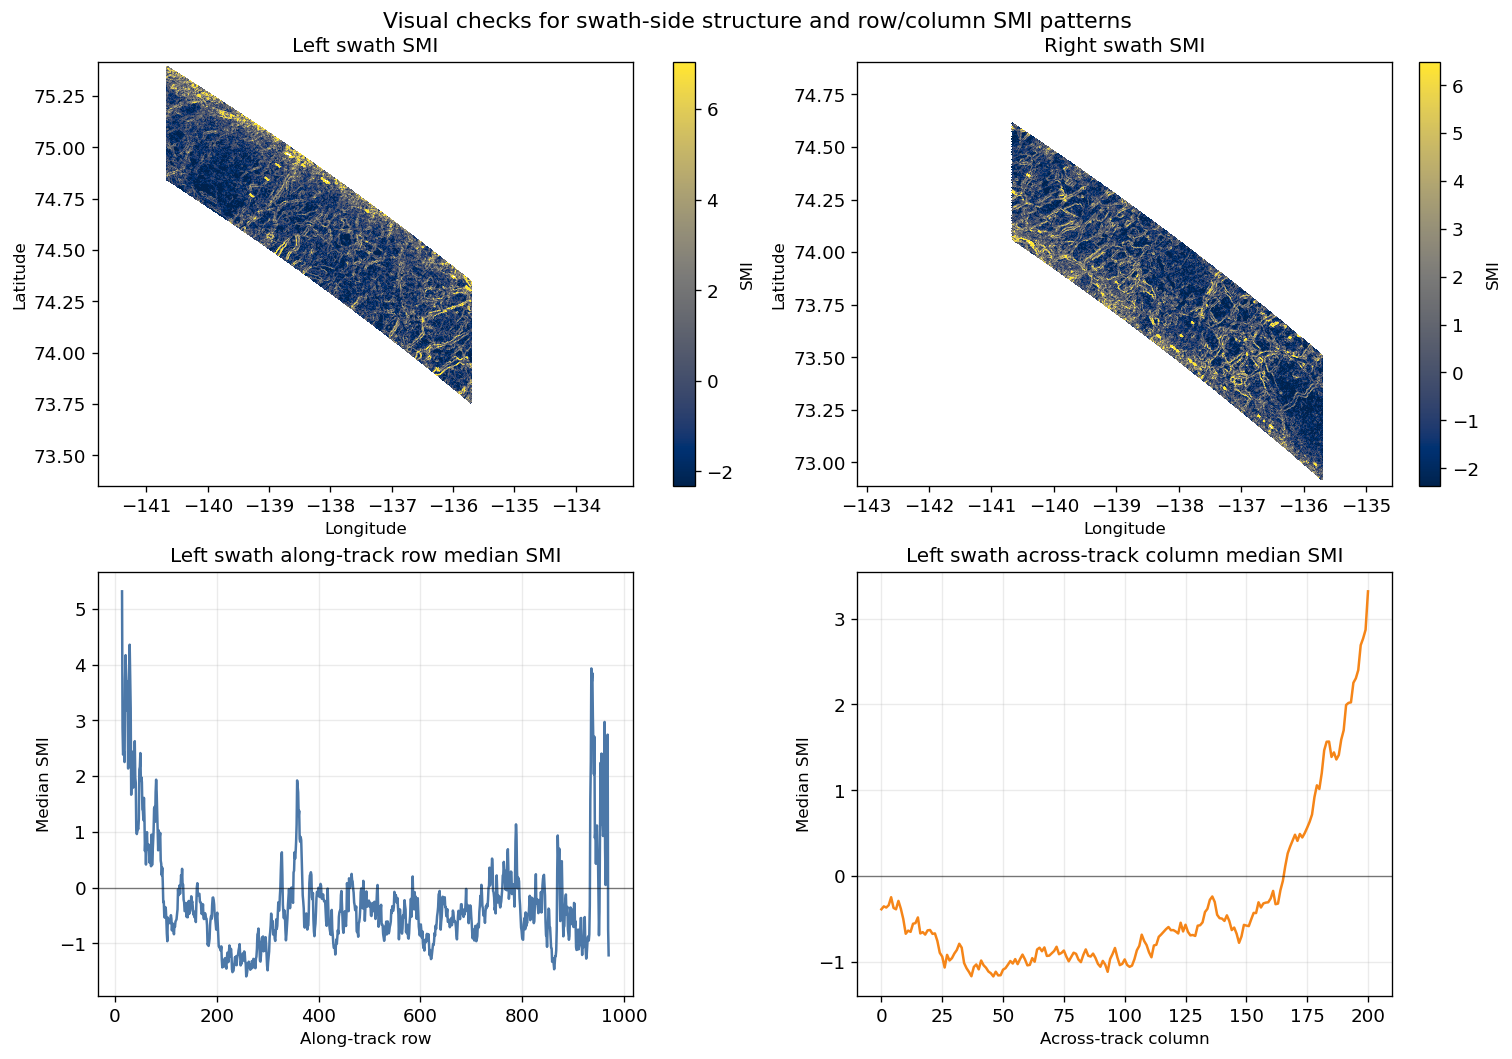

In [16]:
left_row_median = np.nanmedian(np.where(valid, smi, np.nan), axis=1)
left_col_median = np.nanmedian(np.where(valid, smi, np.nan), axis=0)
right_valid = right_metrics["valid_mask"].values.astype(bool)
right_masked_smi = np.where(right_valid, right_smi, np.nan)
right_limits = (np.nanpercentile(right_masked_smi, 5), np.nanpercentile(right_masked_smi, 99))

fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.5), constrained_layout=True)

im = axes[0, 0].pcolormesh(lon, lat, masked_smi, shading="auto", cmap="cividis", vmin=smi_limits[0], vmax=smi_limits[1])
axes[0, 0].set_title("Left swath SMI")
fig.colorbar(im, ax=axes[0, 0], label="SMI")

im = axes[0, 1].pcolormesh(right_swot["lon"], right_swot["lat"], right_masked_smi, shading="auto", cmap="cividis", vmin=right_limits[0], vmax=right_limits[1])
axes[0, 1].set_title("Right swath SMI")
fig.colorbar(im, ax=axes[0, 1], label="SMI")

axes[1, 0].plot(left_row_median, color="#4c78a8")
axes[1, 0].axhline(0, color="black", linewidth=0.8, alpha=0.5)
axes[1, 0].set_title("Left swath along-track row median SMI")
axes[1, 0].set_xlabel("Along-track row")
axes[1, 0].set_ylabel("Median SMI")
axes[1, 0].grid(alpha=0.25)

axes[1, 1].plot(left_col_median, color="#f58518")
axes[1, 1].axhline(0, color="black", linewidth=0.8, alpha=0.5)
axes[1, 1].set_title("Left swath across-track column median SMI")
axes[1, 1].set_xlabel("Across-track column")
axes[1, 1].set_ylabel("Median SMI")
axes[1, 1].grid(alpha=0.25)

for ax in axes[0, :]:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

fig.suptitle("Visual checks for swath-side structure and row/column SMI patterns", y=1.02)
fig_path = FIG_DIR / "smi_artifact_checks_region02_20230409.png"
fig.savefig(fig_path, bbox_inches="tight")
fig_path

## 8. Multi-Date SMI Persistence

The dataset includes three Region 02 SWOT scenes:

| Date | File |
|------|------|
| 2023-04-09 | UMD_SWOT_024_BeaufortSea_Study_Region_02_20230409.nc |
| 2023-04-10 | UMD_SWOT_024_BeaufortSea_Study_Region_02_20230410.nc |
| 2023-06-16 | UMD_SWOT_024_BeaufortSea_Study_Region_02_20230616.nc |

If the SMI is tracking real structural features rather than scene-specific noise, high-index areas should be spatially consistent across dates — at minimum for the two consecutive-day scenes (April 9 and 10), and to some degree for June if the same morphological features persist into late spring.

This section:

1. Computes SMI for each date on its native swath grid (1 km window, left swath).
2. Projects all three high-index masks onto a common 0.01° regular grid.
3. Counts how many dates each cell is high-index (0, 1, 2, or 3).
4. Computes pairwise Jaccard similarity between date pairs over their shared spatial coverage.

**Interpretation guide:**
- High Jaccard between April 9 and April 10 (consecutive days) suggests the index is not dominated by single-pass noise.
- Elevated Jaccard between April and June suggests morphological features persist seasonally, consistent with grounded ridges or robust anchoring features.
- Low Jaccard across all pairs suggests the index needs further refinement before persistence analysis is meaningful.


In [17]:
REGION02_FILES = [
    (DATA_DIR / "UMD_SWOT_024_BeaufortSea_Study_Region_02_20230409.nc", "2023-04-09"),
    (DATA_DIR / "UMD_SWOT_024_BeaufortSea_Study_Region_02_20230410.nc", "2023-04-10"),
    (DATA_DIR / "UMD_SWOT_024_BeaufortSea_Study_Region_02_20230616.nc", "2023-06-16"),
]

scenes = []
for path, date_label in REGION02_FILES:
    ds = swot_utils.open_swot(path, swath="left")
    h = ds["height"].values.astype(float)
    s = ds["sigma0"].values.astype(float)
    vmask, _ = swot_utils.provisional_ice_mask(h, sigma0=s)
    met = swot_utils.compute_morphology(ds, window_m=1000, valid_mask=vmask)
    smi_arr = met["stability_morphology_index"].values
    hi_mask, hi_thresh, hi_label = swot_utils.index_mask(smi_arr, valid_mask=vmask, quantile=0.90)
    scenes.append({
        "date": date_label,
        "lon": ds["lon"].values,
        "lat": ds["lat"].values,
        "smi": smi_arr,
        "valid": vmask,
        "hi_mask": hi_mask,
        "hi_thresh": hi_thresh,
    })
    print(f"{date_label}: {vmask.sum():,} valid pixels, {hi_mask.sum():,} high-index ({hi_label})")

# Project all scenes onto a common 0.01 degree regular grid.
lon_centers, lat_centers = swot_utils.make_common_grid(
    [sc["lon"] for sc in scenes],
    [sc["lat"] for sc in scenes],
    [sc["valid"] for sc in scenes],
    resolution_deg=0.01,
)

for sc in scenes:
    smi_grid, hi_grid = swot_utils.rasterize_smi(
        sc["lon"], sc["lat"], sc["smi"], sc["hi_mask"], sc["valid"],
        lon_centers, lat_centers,
    )
    sc["smi_grid"] = smi_grid
    sc["hi_grid"] = hi_grid

count_grid, coverage_grid = swot_utils.persistence_count(
    [sc["hi_grid"] for sc in scenes], hi_threshold=0.5
)

# Pairwise Jaccard similarity.
dates = [sc["date"] for sc in scenes]
jaccard_rows = []
for i in range(len(scenes)):
    for j in range(i + 1, len(scenes)):
        j_val = swot_utils.jaccard_similarity(scenes[i]["hi_grid"], scenes[j]["hi_grid"])
        shared = int((np.isfinite(scenes[i]["hi_grid"]) & np.isfinite(scenes[j]["hi_grid"])).sum())
        jaccard_rows.append({
            "date_a": dates[i], "date_b": dates[j],
            "jaccard": round(float(j_val), 3) if np.isfinite(j_val) else np.nan,
            "shared_cells": shared,
        })
jaccard_table = pd.DataFrame(jaccard_rows)
print("\nPairwise Jaccard similarity (high-index mask, top 10%, 1 km window):")
display(jaccard_table)

for n in range(1, len(scenes) + 1):
    cells = int(np.sum(count_grid == n))
    print(f"Cells high-index on exactly {n} of {len(scenes)} dates: {cells:,}")


2023-04-09: 159,046 valid pixels, 15,886 high-index (top 10%)


2023-04-10: 159,111 valid pixels, 15,893 high-index (top 10%)


2023-06-16: 158,898 valid pixels, 15,871 high-index (top 10%)

Pairwise Jaccard similarity (high-index mask, top 10%, 1 km window):


,date_a,date_b,jaccard,shared_cells
0,2023-04-09,2023-04-10,0.166,29253
1,2023-04-09,2023-06-16,0.071,28981
2,2023-04-10,2023-06-16,0.076,28963


Cells high-index on exactly 1 of 3 dates: 5,618
Cells high-index on exactly 2 of 3 dates: 1,213
Cells high-index on exactly 3 of 3 dates: 115


C:\Users\as1612\AppData\Local\Temp\ipykernel_73592\3252657977.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_persist = plt.cm.get_cmap("YlOrRd", 4)


WindowsPath('figures/smi_persistence_region02_left.png')

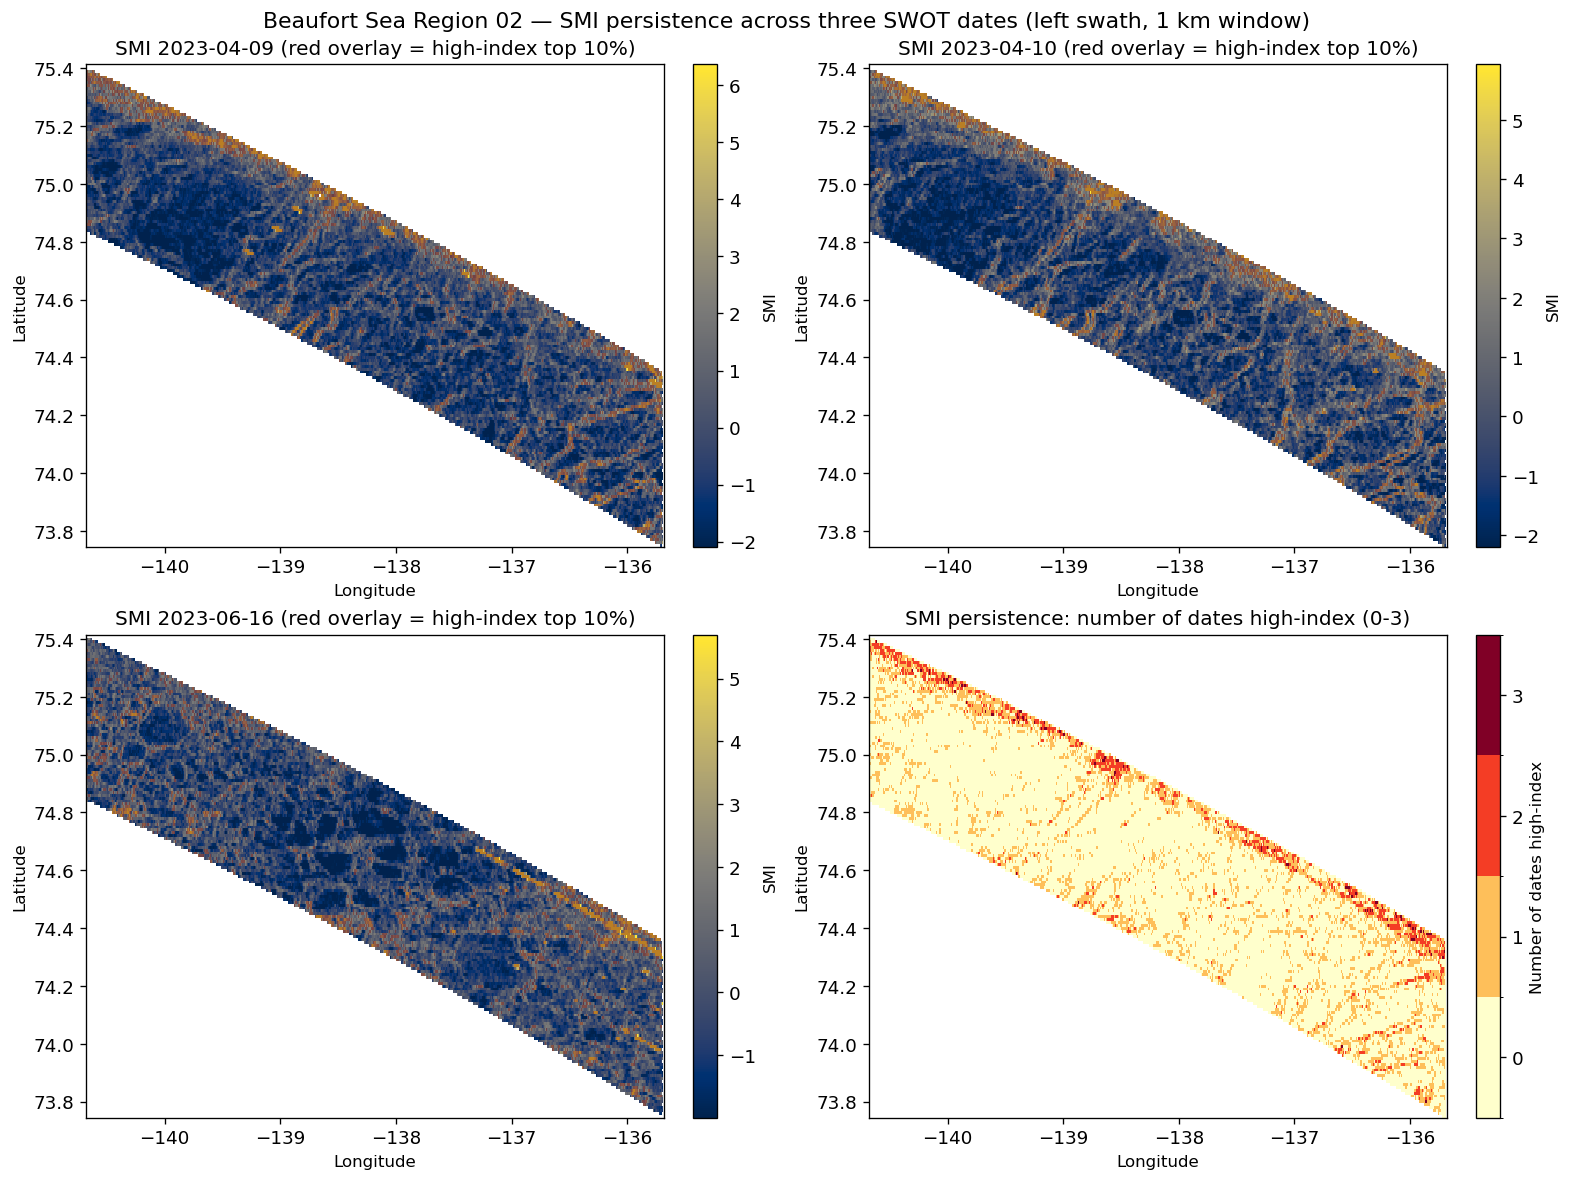

In [18]:
from matplotlib.colors import BoundaryNorm

fig, axes = plt.subplots(2, 2, figsize=(13, 9.5), constrained_layout=True)
lon_grid_2d, lat_grid_2d = np.meshgrid(lon_centers, lat_centers)

for ax, sc in zip(axes.flat[:3], scenes):
    masked_smi = np.where(np.isfinite(sc["smi_grid"]), sc["smi_grid"], np.nan)
    vmin, vmax = np.nanpercentile(masked_smi, 5), np.nanpercentile(masked_smi, 99)
    im = ax.pcolormesh(lon_grid_2d, lat_grid_2d, masked_smi,
                       shading="auto", cmap="cividis", vmin=vmin, vmax=vmax)
    hi_overlay = np.where(sc["hi_grid"] >= 0.5, 1.0, np.nan)
    ax.pcolormesh(lon_grid_2d, lat_grid_2d, hi_overlay,
                  shading="auto", cmap="Reds", alpha=0.45, vmin=0, vmax=1)
    ax.set_title(f"SMI {sc['date']} (red overlay = high-index top 10%)")
    fig.colorbar(im, ax=ax, label="SMI")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

ax4 = axes.flat[3]
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
cmap_persist = plt.cm.get_cmap("YlOrRd", 4)
norm_persist = BoundaryNorm(bounds, cmap_persist.N)
im4 = ax4.pcolormesh(lon_grid_2d, lat_grid_2d,
                     np.where(np.isfinite(count_grid), count_grid, np.nan),
                     shading="auto", cmap=cmap_persist, norm=norm_persist)
fig.colorbar(im4, ax=ax4, ticks=[0, 1, 2, 3], label="Number of dates high-index")
ax4.set_title("SMI persistence: number of dates high-index (0-3)")
ax4.set_xlabel("Longitude")
ax4.set_ylabel("Latitude")

fig.suptitle(
    "Beaufort Sea Region 02 — SMI persistence across three SWOT dates (left swath, 1 km window)",
    y=1.02,
)
fig_path = FIG_DIR / "smi_persistence_region02_left.png"
fig.savefig(fig_path, bbox_inches="tight")
fig_path


## 9. Bathymetric Context

Grounded ridges stabilize Beaufort Sea landfast ice where keel depth exceeds water depth, typically near the ~20 m isobath (Giles et al. 2025; Lemieux et al. 2016). This section checks whether the Region 02 scene is over the shallow shelf where grounding is physically possible.

### Key result: Region 02 is over deep Beaufort Basin water

GEBCO 2023 bathymetry shows all valid SWOT pixels in this scene are in water 3000-3700 m deep. This is the deep Beaufort Basin, not the coastal shelf.

**Implications:**

1. **Grounded ridge anchoring cannot operate here.** Ridge keels cannot reach the seafloor at 3000 m depth. High-index SMI features track dynamic deformation morphology (pressure ridges, rafted ice) rather than grounded structures.

2. **Stability relevance shifts.** In deep-water sea ice, stabilizers are ice-arch geometry and coastal compression -- not grounding. The SMI may still capture morphological signatures of these processes through different physics.

3. **Grounding validation needs coastal scenes.** The Beaufort Sea shelf break is at approximately 70-72 degrees N. Future grounding-depth analysis requires SWOT scenes over water shallower than 50 m, closer to the Alaskan or Canadian coast.

This is a necessary negative constraint: SMI features in Region 02 cannot be grounded ridges, and future work claiming a grounding connection must use a different scene.


In [19]:
valid_lon = swot["lon"].values[valid]
valid_lat = swot["lat"].values[valid]
LON_MIN = float(np.nanmin(valid_lon)) - 0.2
LON_MAX = float(np.nanmax(valid_lon)) + 0.2
LAT_MIN = float(np.nanmin(valid_lat)) - 0.2
LAT_MAX = float(np.nanmax(valid_lat)) + 0.2
print(f"Study bbox: lon [{LON_MIN:.2f}, {LON_MAX:.2f}], lat [{LAT_MIN:.2f}, {LAT_MAX:.2f}]")

bathy_ds = swot_utils.download_bathymetry(
    LON_MIN, LON_MAX, LAT_MIN, LAT_MAX,
    cache_dir=DATA_DIR,
    resolution_deg=0.01,
)

elev_var = "elevation" if "elevation" in bathy_ds else list(bathy_ds.data_vars)[0]
lon_var = "lon" if "lon" in bathy_ds.coords else "longitude"
lat_var = "lat" if "lat" in bathy_ds.coords else "latitude"

bathy_lon = bathy_ds[lon_var].values
bathy_lat = bathy_ds[lat_var].values
bathy_elev = bathy_ds[elev_var].values

depth_min = float(np.nanmin(bathy_elev))
depth_max = float(np.nanmax(bathy_elev))
print(f"Bathymetry depth range: {depth_min:.0f} m to {depth_max:.0f} m")
print(f"Shallowest pixel in scene: {depth_max:.0f} m")
print("=> All pixels are over deep Beaufort Basin. Grounded ridge anchoring is NOT applicable.")

from scipy.spatial import cKDTree
blon_2d, blat_2d = np.meshgrid(bathy_lon, bathy_lat)
finite_b = np.isfinite(bathy_elev.ravel())
transformer_b = swot_utils.local_projector(blon_2d.ravel()[finite_b], blat_2d.ravel()[finite_b])
bx, by = transformer_b.transform(blon_2d.ravel()[finite_b], blat_2d.ravel()[finite_b])
tree_b = cKDTree(np.column_stack([bx, by]))
vx, vy = transformer_b.transform(valid_lon, valid_lat)
dist_b, idx_b = tree_b.query(np.column_stack([vx, vy]), k=1)
depth_at_valid = np.where(dist_b <= 5000, bathy_elev.ravel()[finite_b][idx_b], np.nan)

depth_grid = np.full(swot["height"].shape, np.nan)
valid_indices = np.argwhere(valid)
for idx_v, (gi, gj) in enumerate(valid_indices):
    depth_grid[gi, gj] = depth_at_valid[idx_v]

depth_bins_actual = [0, -1000, -2000, -3000, -3500, -np.inf]
depth_table = swot_utils.smi_by_depth_bin(
    smi, depth_grid, valid, high_index_mask, bins=depth_bins_actual
)
print()
print("SMI statistics by water depth bin (deep Beaufort Basin):")
display(depth_table)
print()
print("For reference, grounding-relevant depths (0 to -50 m) are absent in this scene.")


Study bbox: lon [-140.87, -135.49], lat [73.55, 75.60]
Bathymetry depth range: -3690 m to -3038 m
Shallowest pixel in scene: -3038 m
=> All pixels are over deep Beaufort Basin. Grounded ridge anchoring is NOT applicable.



SMI statistics by water depth bin (deep Beaufort Basin):


,depth_bin,n_pixels,mean_smi,p90_smi,high_index_fraction
0,-3500 to -3000 m,95337,0.02863,2.501608,0.098598
1,< -3500 m,63519,-0.04395,2.573632,0.102111



For reference, grounding-relevant depths (0 to -50 m) are absent in this scene.


WindowsPath('figures/smi_bathymetry_context_region02.png')

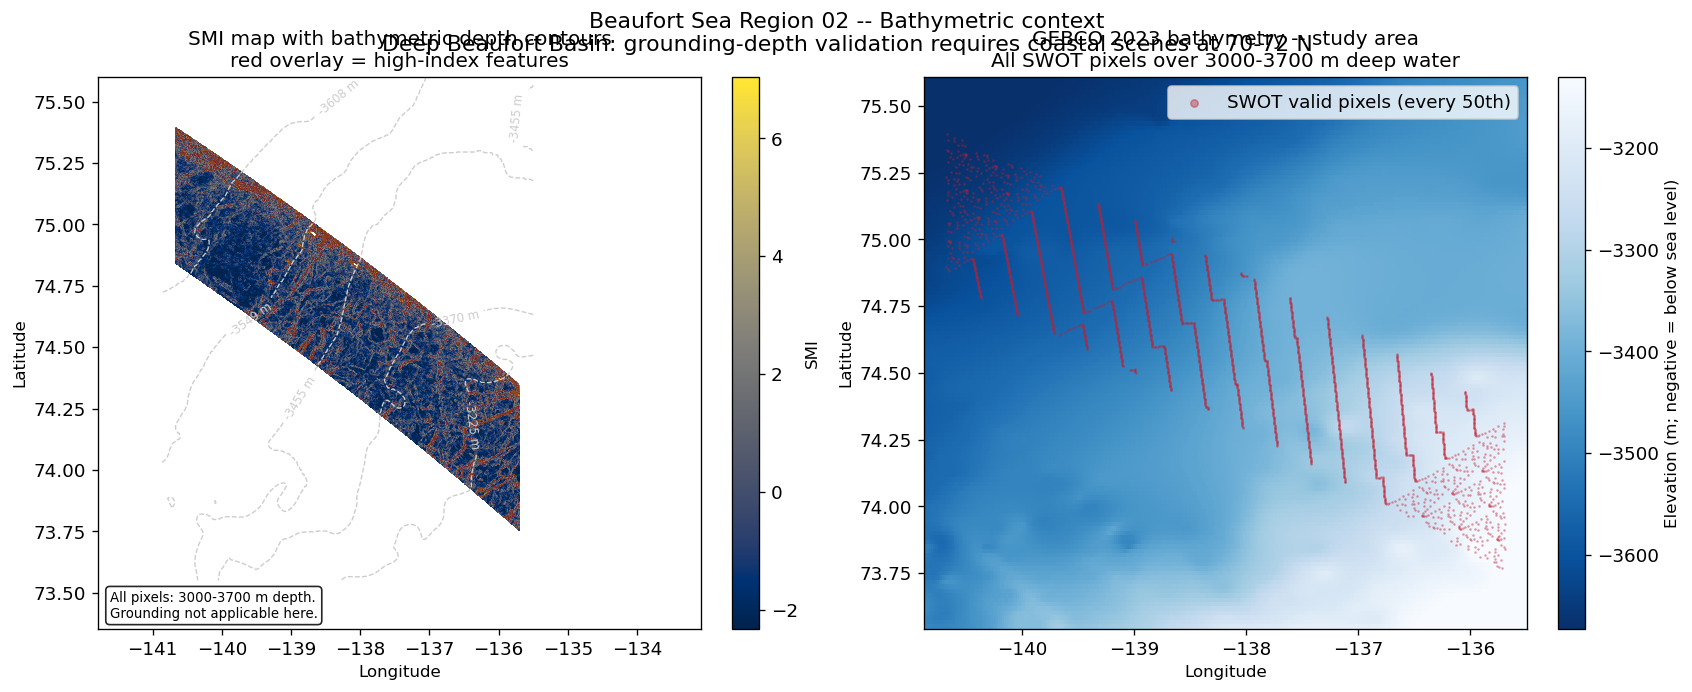

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

masked_smi_plot = np.where(valid, smi, np.nan)
im = axes[0].pcolormesh(lon, lat, masked_smi_plot, shading="auto",
                        cmap="cividis", vmin=smi_limits[0], vmax=smi_limits[1])
try:
    blon_plot, blat_plot = np.meshgrid(bathy_lon, bathy_lat)
    depth_levels = sorted(set(
        [int(np.nanpercentile(bathy_elev, p)) for p in [10, 25, 50, 75, 90]]
    ))
    cs = axes[0].contour(blon_plot, blat_plot, bathy_elev, levels=depth_levels,
                         colors="#cccccc", linewidths=0.8)
    axes[0].clabel(cs, fmt="%d m", fontsize=7)
except Exception:
    pass
hi_plot = np.where(high_index_mask, 1.0, np.nan)
axes[0].pcolormesh(lon, lat, hi_plot, shading="auto", cmap="Reds", alpha=0.45, vmin=0, vmax=1)
fig.colorbar(im, ax=axes[0], label="SMI")
axes[0].set_title("SMI map with bathymetric depth contours\nred overlay = high-index features")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].annotate(
    "All pixels: 3000-3700 m depth.\nGrounding not applicable here.",
    xy=(0.02, 0.02), xycoords="axes fraction", fontsize=8,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85),
)

try:
    blon_plot, blat_plot = np.meshgrid(bathy_lon, bathy_lat)
    im2 = axes[1].pcolormesh(blon_plot, blat_plot, bathy_elev,
                              shading="auto", cmap="Blues_r",
                              vmin=np.nanpercentile(bathy_elev, 2),
                              vmax=np.nanpercentile(bathy_elev, 98))
    fig.colorbar(im2, ax=axes[1], label="Elevation (m; negative = below sea level)")
    axes[1].scatter(valid_lon[::50], valid_lat[::50], s=0.3, c="#c21f32", alpha=0.4,
                    label="SWOT valid pixels (every 50th)")
    axes[1].set_title("GEBCO 2023 bathymetry -- study area\nAll SWOT pixels over 3000-3700 m deep water")
    axes[1].set_xlabel("Longitude")
    axes[1].set_ylabel("Latitude")
    axes[1].legend(frameon=True, markerscale=8)
except Exception as e:
    axes[1].text(0.5, 0.5, str(e), transform=axes[1].transAxes, ha="center", va="center")

fig.suptitle(
    "Beaufort Sea Region 02 -- Bathymetric context\n"
    "Deep Beaufort Basin: grounding-depth validation requires coastal scenes at 70-72 N",
    y=1.02,
)
fig_path = FIG_DIR / "smi_bathymetry_context_region02.png"
fig.savefig(fig_path, bbox_inches="tight")
fig_path


## 10. 2D Spatial Structure of the SMI

This is the analysis that only SWOT can provide. ICESat-2 gives a 1D profile; SWOT gives a 100 km-wide 2D swath. The question is what new information the 2D coverage adds beyond what can be learned from a single track.

Three analyses:

1. **Semi-variogram**: How does SMI autocorrelation decay with distance? The range at which the variogram plateaus is the spatial correlation length -- the characteristic scale of rough and smooth ice zones. This is a parameter needed for model drag parameterisation and for designing future sampling strategies.

2. **Feature shape metrics**: For each connected high-index feature, compute area, elongation ratio, and orientation angle. Do features have a preferred orientation? Ridges form perpendicular to the principal compressive stress, so systematic orientation would encode the deformation history.

3. **Multi-date structure comparison**: Does the spatial correlation length or feature anisotropy change between April and June? A change in correlation length would indicate a change in the scale of active deformation.

**Why this matters:** No published SWOT paper has reported spatial correlation length or feature anisotropy for sea-ice morphology. These are the quantities that justify using a 2D instrument rather than a 1D one.


In [21]:
# -- Semi-variogram of the April 9 SMI --
variogram = swot_utils.smi_variogram(
    smi, valid,
    swot["lon"].values, swot["lat"].values,
    max_distance_m=60_000,
    n_bins=24,
    n_sample=6000,
)
print("Semi-variogram (first 6 rows):")
display(variogram.head(6))

# Estimate spatial correlation length as the lag where semivariance
# first reaches 95% of the sill (median of the top 25% of values).
sill = float(variogram["semivariance"].quantile(0.75))
nugget = float(variogram["semivariance"].iloc[0])
threshold = nugget + 0.95 * (sill - nugget)
reaches = variogram[variogram["semivariance"] >= threshold]
correlation_length_m = float(reaches["distance_m"].iloc[0]) if not reaches.empty else np.nan
print(f"\nEstimated spatial correlation length: {correlation_length_m/1000:.1f} km")
print(f"Sill (p75 semivariance): {sill:.3f}")
print(f"Nugget (first lag): {nugget:.3f}")


Semi-variogram (first 6 rows):


,distance_m,semivariance,n_pairs
0,1250.0,3.127489,36175
1,3750.0,3.867201,102706
2,6250.0,3.670590,167137
3,8750.0,3.821177,221186
4,11250.0,3.843130,271181
5,13750.0,3.867264,317696



Estimated spatial correlation length: 41.2 km
Sill (p75 semivariance): 5.400
Nugget (first lag): 3.127


In [22]:
# -- Feature shape metrics for April 9 high-index features --
shape_metrics = swot_utils.feature_shape_metrics(
    feature_labels, spacing=spacing, min_pixels=10
)
print(f"Features analysed: {len(shape_metrics)}")
print(f"Median elongation ratio: {shape_metrics['elongation'].median():.2f}")
print(f"Median eccentricity:     {shape_metrics['eccentricity'].median():.2f}")
print(f"Median major axis:       {shape_metrics['axis_major_km'].median():.2f} km")
print(f"Orientation range:       {shape_metrics['orientation_deg'].min():.0f} to "
      f"{shape_metrics['orientation_deg'].max():.0f} deg")
display(shape_metrics.sort_values("area_km2", ascending=False).head(10))


Features analysed: 224
Median elongation ratio: 2.43
Median eccentricity:     0.91
Median major axis:       2.38 km
Orientation range:       -90 to 90 deg


,feature_id,area_km2,eccentricity,orientation_deg,axis_major_km,axis_minor_km,elongation
18,30,64.569907,0.983188,12.647874,27.651793,5.049114,5.476564
38,82,60.560469,0.879414,-2.997860,17.146002,8.162480,2.100587
5,7,51.823484,0.802769,-2.451221,15.083044,8.993878,1.677034
186,376,33.032983,0.628293,-89.698898,12.408569,9.653583,1.285385
112,210,29.981023,0.920751,5.078009,14.220012,5.547956,2.563109
0,1,29.143230,0.942473,-1.943457,14.179882,4.740095,2.991476
196,392,22.740097,0.997024,64.783245,22.063684,1.700887,12.971866
202,401,15.798383,0.933175,77.038701,12.148460,4.366415,2.782250
215,432,13.524373,0.992061,68.318218,17.391432,2.187097,7.951832
205,404,12.626738,0.985603,66.383594,18.206058,3.078240,5.914438


In [23]:
# -- Multi-date semi-variograms (all three Region 02 dates) --
variograms_by_date = {}
for sc in scenes:
    vg = swot_utils.smi_variogram(
        sc["smi"], sc["valid"],
        sc["lon"], sc["lat"],
        max_distance_m=60_000, n_bins=24, n_sample=4000,
    )
    vg["date"] = sc["date"]
    variograms_by_date[sc["date"]] = vg
    sill_i = float(vg["semivariance"].quantile(0.75))
    nugget_i = float(vg["semivariance"].iloc[0])
    thresh_i = nugget_i + 0.95 * (sill_i - nugget_i)
    reaches_i = vg[vg["semivariance"] >= thresh_i]
    cl_i = float(reaches_i["distance_m"].iloc[0]) / 1000 if not reaches_i.empty else np.nan
    print(f"{sc['date']}: correlation length ~ {cl_i:.1f} km, sill ~ {sill_i:.3f}, nugget ~ {nugget_i:.3f}")


2023-04-09: correlation length ~ 41.2 km, sill ~ 5.777, nugget ~ 3.376


2023-04-10: correlation length ~ 41.2 km, sill ~ 5.033, nugget ~ 3.172


2023-06-16: correlation length ~ 38.8 km, sill ~ 6.107, nugget ~ 4.157


WindowsPath('figures/smi_2d_spatial_structure_region02.png')

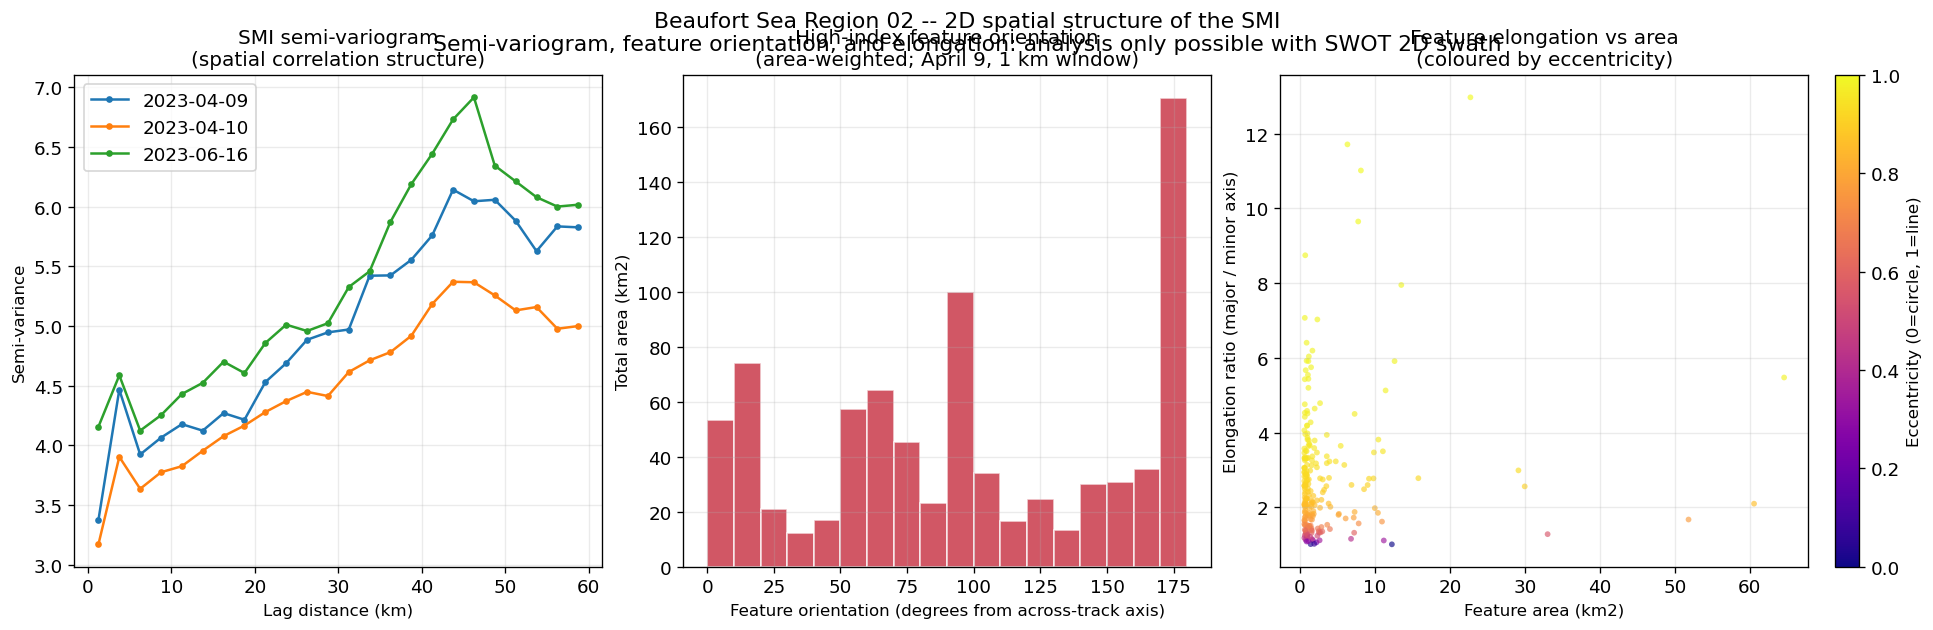

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

# Panel 1: semi-variogram for all three dates
colors_vg = {"2023-04-09": "#1f77b4", "2023-04-10": "#ff7f0e", "2023-06-16": "#2ca02c"}
for date, vg in variograms_by_date.items():
    axes[0].plot(vg["distance_m"] / 1000, vg["semivariance"],
                 marker="o", markersize=3, linewidth=1.5,
                 color=colors_vg[date], label=date)
axes[0].set_xlabel("Lag distance (km)")
axes[0].set_ylabel("Semi-variance")
axes[0].set_title("SMI semi-variogram\n(spatial correlation structure)")
axes[0].legend(frameon=True)
axes[0].grid(alpha=0.25)

# Panel 2: feature orientation rose diagram
if not shape_metrics.empty:
    angles = shape_metrics["orientation_deg"].dropna().values
    # Orientation is in [-90, 90]; wrap to [0, 180] for a rose diagram
    angles_180 = angles % 180
    bins_rose = np.linspace(0, 180, 19)
    counts, _ = np.histogram(angles_180, bins=bins_rose,
                              weights=shape_metrics["area_km2"].values[:len(angles_180)])
    bin_centers = (bins_rose[:-1] + bins_rose[1:]) / 2
    axes[1].bar(bin_centers, counts, width=10, color="#c21f32", alpha=0.75, edgecolor="white")
    axes[1].set_xlabel("Feature orientation (degrees from across-track axis)")
    axes[1].set_ylabel("Total area (km2)")
    axes[1].set_title("High-index feature orientation\n(area-weighted; April 9, 1 km window)")
    axes[1].grid(alpha=0.25)

# Panel 3: elongation vs area scatter
if not shape_metrics.empty:
    sc_plot = shape_metrics[shape_metrics["elongation"] <= 20]
    axes[2].scatter(sc_plot["area_km2"], sc_plot["elongation"],
                    s=12, c=sc_plot["eccentricity"], cmap="plasma",
                    alpha=0.65, linewidths=0)
    sm = plt.cm.ScalarMappable(cmap="plasma",
                                norm=plt.Normalize(0, 1))
    sm.set_array([])
    fig.colorbar(sm, ax=axes[2], label="Eccentricity (0=circle, 1=line)")
    axes[2].set_xlabel("Feature area (km2)")
    axes[2].set_ylabel("Elongation ratio (major / minor axis)")
    axes[2].set_title("Feature elongation vs area\n(coloured by eccentricity)")
    axes[2].grid(alpha=0.25)

fig.suptitle(
    "Beaufort Sea Region 02 -- 2D spatial structure of the SMI\n"
    "Semi-variogram, feature orientation, and elongation: analysis only possible with SWOT 2D swath",
    y=1.02,
)
fig_path = FIG_DIR / "smi_2d_spatial_structure_region02.png"
fig.savefig(fig_path, bbox_inches="tight")
fig_path


### Interpretation

**Spatial correlation length**: the lag at which the semi-variogram plateaus gives the characteristic scale of morphologically coherent ice zones. If this is O(5-20 km), it is consistent with the scale of pressure-ridge systems and deformation bands. If it is much shorter (< 2 km), the SMI is dominated by pixel-scale noise rather than physical structure.

**Feature orientation**: if high-index features have a preferred orientation, that direction is likely perpendicular to the dominant compressive stress axis in the period before the scene. Systematic orientation across all three dates would be consistent with a persistent deformation regime. Random orientation would suggest the SMI is not resolving organised ridge systems.

**Multi-date correlation length**: if the spatial correlation length is stable between April 9, April 10, and June 16, the 2D structure is persistent. If it changes substantially between April and June, that may reflect seasonal evolution in the deformation regime or in SWOT's sensitivity to surface melt.

**Comparison with 1D**: A single ICESat-2 track through this scene provides one realisation of the roughness structure. The SWOT semi-variogram uses the full 2D field and provides a spatially representative characterisation. The difference between the two is the core scientific justification for using SWOT for ice morphology rather than relying on along-track instruments alone.


## Future Validation Layers

1. **Breakout prediction layer**
   Compare SWOT roughness/ridge/anchor metrics before breakup against observed breakup locations or dates.

2. **SAR persistence layer**
   Use Sentinel-1 to classify landfast versus mobile ice before and after the SWOT scene, then test whether SWOT morphology predicts which zones remain attached.

3. **Bathymetric grounding layer**
   Combine SWOT roughness features with bathymetry to identify candidate grounded ridges or shallow-water anchoring zones, then test whether high-roughness features occur at plausible grounding depths.

4. **Model-parameterization layer**
   Convert SWOT-derived roughness, ridge density, or morphology-index statistics into parameters relevant to coastal drag, internal ice strength, or landfast-ice anchoring in models.

5. **Algorithmic uncertainty layer**
   Quantify how stable the morphology index is under swath-side differences, window size, threshold choice, score-component choice, and known SWOT sea-ice artifacts.

The current notebook prioritizes the fifth layer because it is doable immediately with the existing dataset.

## Interpretation Notes

In this case scene, the SWOT fields show coherent 2D height and backscatter structures that survive a simple local-morphology index workflow. The high-index mask highlights a connected network of roughness, gradient, and backscatter-texture anomalies. Along the spatially overlapping ICESat-2 beam, top sampled SMI values have somewhat higher local ICESat-2 height variability than background sampled values, which is consistent with enhanced surface morphology but does not prove grounding, anchoring, thickness, or stability.

The method is useful if it produces coherent, robust, interpretable morphology features that can be carried forward into future validation against breakout or persistence data. High-index areas are candidate morphology features only. They are not confirmed grounded ridges, anchor points, thickness anomalies, or stable landfast-ice zones.